# Sample alignment

This tutorial describes the steps that are taken to set up the beamline and perform sample alignment near the beginning of a beam time.  It also allows viewing raw data from scans.  For more detailed data reduction and analysis, see other notebooks.

## Imports and other setup

Before using this notebook, ensure that python has been set up correctly (e.g., https://github.com/NSLS-II-SST/rsoxs_workflow/blob/Issue46_PythonSetupExample_Draft/examples/setup_python_miniforge.md)

### Import PyHyperScattering and other libraries as needed

In [2]:
## Cannot put a comment on the same line where % is used
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import PyHyperScattering as phs
print(f'Using PyHyper Version: {phs.__version__}')

import sys
print(f"Python version {sys.version}.  Version info. {sys.version_info}")
import os
#from IPython import display
#import pathlib
#basePath = pathlib.Path('.').absolute()

## Data storage and manipulation
import numpy as np
import pandas as pd
import xarray as xr ## !pip install xarray==2022.3
import zarr
import json
import math
import copy
import datetime
import inspect
import re
import scipy
#import natsort ## !pip install natsort

## Plotting
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import LogNorm ## For log scaling in imshow
from matplotlib.pyplot import cm
import matplotlib.dates as mdates
import matplotlib as mpl
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
from matplotlib.colors import Normalize
import matplotlib.patches as patches
from matplotlib.path import Path
#import imageio ## For putting together movies

## Image processing
from PIL import Image

  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/home/hduva/.local/share/uv/python/cpython-3.12.8-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py", line 640, in run_forever
    self._run_once()
  File "/home/hduva/.local/share/uv/python/cpython-3.12.8-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py"

Using PyHyper Version: 0.2.10
Python version 3.12.8 (main, Dec 19 2024, 14:33:20) [Clang 18.1.8 ].  Version info. sys.version_info(major=3, minor=12, micro=8, releaselevel='final', serial=0)


### Load local functions

Below are some functions that can assist data viewing and processing.  On the left-hand panel, select the table of contents, right click on the "Load local functions" heading, and click on "Select and Run Cell(s) for this Heading"

#### View and export energy scans

In [29]:
def view_export_energy_scans(
    scan_ids,
    export_scans = False,
    file_path_export = "",
    file_name_export = "",
    signals_to_plot = ["I0", "Photodiode"],
    figure_title = "",
    energies_vline = [],
):
    """
    Load the 1D detector data directly from Tiled and show a basic plot of the raw data and normalized signal.
    In many cases, this code is used to gather several scans across time, which can take a long time to load.
    Thus, the workflow is broken up such that the code below mainly gathers the data and can save into Excel files.
    Then, these Excel files can be loaded to do further processing, which can be more time-efficient than reloading the entire start-to-finish process.

    Args:
        scan_ids: list of int values
            List of scan IDs to process.
        export_scans: bool
            True exports scan data into Excel file.
            Defaults to False to skip export step.
        file_path_export: str
            File path, not including file name, to export data.
            Defaults to empty string corresponding with export_scans = False
        file_name_export: str
            File name of exported data.
            Defaults to empty string corresponding with export_scans = False
        signals_to_plot: list of str values, length 2
            Signals to show in the plots.
            Defaults to I0 and Photodiode signals.  This is useful for open-beam scans which can assess contamination on these detectors or upstream optics, provide a proxy for the beam flux with respect to energy and time, and characterize stability of the normalized signal over time.
            Another option is to use ["I0", "TEY"] for TEY samples, such as HOPG.  This is useful for monitoring shifts in energy calibration or changes to the TEY sample.
        figure_title: str
            Optional title to add to figure
        energies_vlines: list of float values
            Optional list of energies at which vertical lines can be plotted.
            Vertical lines can help mark any features that occur at particular energies.
            Defaults to empty list.

    Returns:
        Optionally explorts scan data into excel file.
        Plots raw and normalized signals.

    Raises:

    Examples:
    """

    ## TODO: use a universal lookup table and function to assign variable names
    ## Use this to include slit currents in the exported data
    ## Plot slit currents by having it as the two signals in the next viewing step.

    offset_timestamp_seconds = 0 ## TODO: revisit if there is a better way to get the correct time.  In Google Colab, sometimes it shifted the timestamp by 4 hours.

    number_rows, number_columns = 1, 3
    fig, axs = plt.subplots(number_rows, number_columns, figsize=(number_columns*5, number_rows*4), edgecolor=(0, 0, 0, 0), linewidth=3) #figsize=(3.25, 3.25) for figure
    fig.suptitle(figure_title, color=(0, 0, 0, 1), fontname="Calibri", size=12)
    ## Ensure axs always stays a 2D array
    if number_rows == 1 and number_columns == 1: axs = np.array([[axs]])
    if number_rows == 1 and number_columns > 1: axs = axs.reshape(1, number_columns)
    if number_rows > 1 and number_columns == 1: axs = axs.reshape(number_rows, 1)
    plot_colors = cm.rainbow(np.linspace(1, 0, len(scan_ids)))

    for index_scan_id, scan_id in enumerate(scan_ids):
        plot_color = plot_colors[index_scan_id]

        ## Load scan
        scan_raw = catalog[int(scan_id)]
        scan_xarray = scan_raw["primary"]["data"].read()
        scan_xarray = scan_xarray.rename_vars({"en_energy": "Energy"})
        scan_xarray = scan_xarray.rename_vars({"RSoXS Au Mesh Current": "I0"})
        scan_xarray = scan_xarray.rename_vars({"DM7 photodiode": "Photodiode"}) #scan_xarray = scan_xarray.rename_vars({"WAXS Beamstop": "Photodiode"})
        scan_xarray = scan_xarray.rename_vars({"RSoXS Sample Current": "TEY"})
        scan = copy.deepcopy(scan_xarray)

        ## Export scan
        if export_scans:
            sheet_name = "ScanID" + str(scan_id)
            scan_dictionary = {
                "Energy": scan["Energy"],
                "I0": scan["I0"],
                "Photodiode": scan["Photodiode"],
                "TEY": scan["TEY"],
                "ScanID": int(scan_id),
                "Timestamp_Seconds": (scan_raw.metadata["start"]["time"] - offset_timestamp_seconds)
            }
            scan_dataframe = pd.DataFrame(scan_dictionary)
            if os.path.exists(os.path.join(file_path_export, file_name_export)):
                with pd.ExcelWriter(os.path.join(file_path_export, file_name_export), mode='a') as writer: ## If the file already exists, it will just add a new sheet, otherwise create a new file.  Or maybe not?  Revisit how this works.
                    scan_dataframe.to_excel(writer, sheet_name=sheet_name, index=True)
            else:
                scan_dataframe.to_excel(os.path.join(file_path_export, file_name_export), sheet_name=sheet_name, index=True)

        ## Gather plot labels and information to print to serve as a progress bar
        polarization = scan_raw["baseline"]["data"]["en_polarization"].read()[0]
        timestamp = str(datetime.datetime.fromtimestamp(int(scan_raw.metadata["start"]["time"] - offset_timestamp_seconds)))
        plot_label = "Scan ID = " + str(scan_id) + ", \nTime = " + str(timestamp)
        print("Scan ID = " + str(scan_id) + ", Time = " + str(timestamp) + ", Polarization = " + str(polarization) + "°")

        ## Plot data
        ax = axs[0, 0]
        ax.plot(scan["Energy"], scan[signals_to_plot[0]], label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel(str(signals_to_plot[0]), color=(0, 0, 0, 1), size=12)
        ax = axs[0, 1]
        ax.plot(scan["Energy"], scan[signals_to_plot[1]], label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel((str(signals_to_plot[1]) + " signal"), color=(0, 0, 0, 1), size=12)
        ax = axs[0, 2]
        ax.plot(scan["Energy"], scan[signals_to_plot[0]]/scan[signals_to_plot[1]], label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel((str(signals_to_plot[0]) + " / " + str(signals_to_plot[1]) + " signal"), color=(0, 0, 0, 1), size=12)


    ## Mark energies
    for energy_vline in energies_vline:
        for subplot in [0, 1, 2]:
            ax = axs[0, subplot]
            ax.axvline(energy_vline, color=(0, 0, 0, 1), linestyle="dashed")

    ## Plot Formatting
    for index_row in np.arange(0, number_rows, 1):
        for index_column in np.arange(0, number_columns, 1):
            ax = axs[index_row, index_column]
            ## Subplot and axes labels
            ax.set_xlabel("Energy (eV)", color=(0, 0, 0, 1), size=12)
            #ax.set_ylabel("I0", color=(0, 0, 0, 1), size=12)
            ## Axes scaling and ranges
            ax.set_xscale("linear")
            ax.set_yscale("linear")
            #ax.set_xlim([0, 0.08])
            ax.set_ylim(bottom=0, top=None, auto=True)
            ## Border formatting
            for Border in np.array(["top", "bottom", "left", "right"]):
                ax.spines[Border].set_linewidth(2) ## axes/border linewidths
                ax.spines[Border].set_color((0, 0, 0, 1)) ## axes/border colors
            for Axis in np.array(["x", "y"]): ax.tick_params(axis=Axis, colors=(0, 0, 0, 1), width=2)
    axs[0, 2].legend(ncol=1, loc="center left", bbox_to_anchor=(1.05, 0.5), edgecolor=(1, 1, 1, 1))
    plt.tight_layout() ## This ensures that subplots don't overlap
    return axs





def view_energy_scans(
    file_path_import,
    file_name_import,
    sheet_names,
    signals_to_plot = ["I0", "Photodiode"],
    darks = [0, 0],
    energy_time_plot = 285,
    figure_title = "",
    energies_vline = [],
):
    """
    This will load energy scan data that has been exported into a spreadsheet.
    The energy scan data is processed further to subtract dark values and to extract the time dependence of signal intensities.

    Args:
        file_path_import: str
            File path to the excel spreadsheet.
        file_name_import: str
            File name of the excel spreadsheet that contains energy scan data.
            The file is organized such that each sheet contains data for a single scan, and the sheet name contains the scan ID.
        sheet_names: list of str values
            A list of the sheet names to process.
            Usually, all sheets in a file are analyzed, but optionally, selected sheet names can be provided.
        signals_to_plot: list of str values, length 2
            Signals to show in the plots.
            Defaults to I0 and Photodiode signals.  This is useful for open-beam scans which can assess contamination on these detectors or upstream optics, provide a proxy for the beam flux with respect to energy and time, and characterize stability of the normalized signal over time.
            Another option is to use ["I0", "TEY"] for TEY samples, such as HOPG.  This is useful for monitoring shifts in energy calibration or changes to the TEY sample.
        darks: list of float values
            A list of dark values for the signals measured.
            Order of dark values is the order of the signals_to_plot list.
            Defaults to 0 dark signal if no dark values are entered.
        energy_time_plot: float
            Energy (eV) at which intensities are extracted to view evolution over time.
        energies_vlines: list of float values
            Optional list of energies at which vertical lines can be plotted.
            Vertical lines can help mark any features that occur at particular energies.
            Defaults to empty list.

    Returns:

    Raises:

    Examples:
    """

    number_rows, number_columns = 2, 3
    fig, axs = plt.subplots(number_rows, number_columns, figsize=(number_columns*5, number_rows*5), edgecolor=(0, 0, 0, 0), linewidth=3) #figsize=(3.25, 3.25) for figure
    ## Ensure axs always stays a 2D array
    if number_rows == 1 and number_columns == 1: axs = np.array([[axs]])
    if number_rows == 1 and number_columns > 1: axs = axs.reshape(1, number_columns)
    if number_rows > 1 and number_columns == 1: axs = axs.reshape(number_rows, 1)
    fig.suptitle((figure_title + "\n Dark_" + str(signals_to_plot[0]) + " = " + str(darks[0]) + ", Dark_" + str(signals_to_plot[1]) + " = " + str(darks[1])), color=(0, 0, 0, 1), size=12)
    plot_colors = cm.rainbow(np.linspace(1, 0, len(sheet_names)))

    ax_y1 = axs[1, 1]
    ax_y2 = ax_y1.twinx()

    for index_sheet_name, sheet_name in enumerate(sheet_names):
        plot_color = plot_colors[index_sheet_name]
        scan = pd.read_excel(os.path.join(file_path_import, file_name_import), sheet_name=sheet_name) ## Opening from excel
        scan_id, timestamp_seconds = int(scan["ScanID"][0]), scan["Timestamp_Seconds"][0]

        timestamp_datetime = datetime.datetime.fromtimestamp(int(timestamp_seconds))

        ## Subtract darks
        for signal_to_plot, dark in zip(signals_to_plot, darks):
            scan[signal_to_plot] = scan[signal_to_plot] - dark

        ## Extract signals at selected energy
        signals_single_energy = []
        for signal_to_plot in signals_to_plot:
            scan_sorted_for_interpolation = scan.sort_values(by="Energy").reset_index(drop=True)
            signal_single_energy = np.interp(energy_time_plot,
                                             scan_sorted_for_interpolation["Energy"],
                                             scan_sorted_for_interpolation[signal_to_plot],
                                             left = np.nan, ## Needed to avoid extrapolation for partial datasets that might not contain energy_time_plot within the range of measured energies
                                             right = np.nan,
                                            )
            signals_single_energy.append(signal_single_energy)

        plot_label = " Scan ID = " + str(scan_id)
        print("Scan ID = " + str(scan_id) + ", Time = " + str(timestamp_datetime)) ## Acting as a progress bar

        ax = axs[0, 0]
        ax.plot(scan["Energy"], scan[signals_to_plot[0]], label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel(str(signals_to_plot[0]), color=(0, 0, 0, 1), size=12)

        ax = axs[0, 1]
        ax.plot(scan["Energy"], scan[signals_to_plot[1]], label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel((str(signals_to_plot[1]) + " signal"), color=(0, 0, 0, 1), size=12)

        ax = axs[0, 2]
        ax.plot(scan["Energy"], scan[signals_to_plot[0]]/scan[signals_to_plot[1]], label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel((str(signals_to_plot[0]) + " / " + str(signals_to_plot[1]) + " signal"), color=(0, 0, 0, 1), size=12)

        datapoint, y_axis_label, y_axis_side, y_axis_offset = signals_single_energy[0], (str(signals_to_plot[0]) + " (filled circles)"), "left", 0
        # Plot data
        ax_y1.plot(timestamp_datetime, datapoint, label="", marker="o", markersize=5, markerfacecolor=plot_color, markeredgecolor=plot_color, linestyle="none")
        ax_y1.set_ylabel(y_axis_label, color=(0, 0, 0, 1), size=12)
        ax_y1.set_ylim(bottom=0, top=None, auto=True)
        ax_y1.yaxis.set_label_position(y_axis_side)
        ax_y1.yaxis.set_ticks_position(y_axis_side)
        datapoint, y_axis_label, y_axis_side, y_axis_offset = signals_single_energy[1], (str(signals_to_plot[1]) + " signal (hollow squares)"), "right", 0
        # Plot data
        ax_y2.plot(timestamp_datetime, datapoint, label="", marker="s", markersize=5, markerfacecolor="none", markeredgecolor=plot_color, linestyle="none")
        if index_sheet_name != (len(sheet_names) - 1): ax_y2.set_ylabel(y_axis_label, color=(0, 0, 0, 0), size=12)
        else: ax_y2.set_ylabel(y_axis_label, color=(0, 0, 0, 1), size=12)
        ax_y2.set_ylim(bottom=0, top=None, auto=True)
        ax_y2.yaxis.set_label_position(y_axis_side)
        ax_y2.yaxis.set_ticks_position(y_axis_side)

        ax = axs[1, 2]
        ax.plot(timestamp_datetime, (signals_single_energy[0]/signals_single_energy[1]), label="", marker="o", markersize=5, markerfacecolor=plot_color, markeredgecolor=plot_color, linestyle="none")
        ax.set_ylabel((str(signals_to_plot[0]) + " / " + str(signals_to_plot[1]) + " signal"), color=(0, 0, 0, 1), size=12)


    ## Mark energies
    for energy_vline in energies_vline:
        for subplot in [0, 1, 2]:
            ax = axs[0, subplot]
            ax.axvline(energy_vline, color=(0, 0, 0, 1), linestyle="dashed")

    ## Plot Formatting
    for index_row in np.arange(0, number_rows, 1):
        for index_column in np.arange(0, number_columns, 1):
            ax = axs[index_row, index_column]
            ## Subplot and axes labels
            if index_row == 1 and index_column > 0: ax.set_title((f"Energy = {energy_time_plot} eV"), color=(0, 0, 0, 1), size=12)
            if index_row == 0: ax.set_xlabel("Energy (eV)", color=(0, 0, 0, 1), size=12)
            #ax.set_ylabel("I0", color=(0, 0, 0, 1), size=12)
            ## Axes scaling and ranges
            ax.set_xscale("linear")
            ax.set_yscale("linear")
            #ax.set_xlim([0, 0.08])
            ax.set_ylim(bottom=0, top=None, auto=True)
            ## Border formatting
            for Border in np.array(["top", "bottom", "left", "right"]):
                ax.spines[Border].set_linewidth(2) ## axes/border linewidths
                ax.spines[Border].set_color((0, 0, 0, 1)) ## axes/border colors
            for Axis in np.array(["x", "y"]): ax.tick_params(axis=Axis, colors=(0, 0, 0, 1), width=2)
            if index_row == 1:
                ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M:%S'))
                for label in ax.get_xticklabels():
                    label.set_rotation(45)
                    label.set_horizontalalignment('right')
    axs[1, 0].axis('off') ## To remove plot and axes and have a blank spot
    plt.tight_layout() ## This ensures that subplots don't overlap

    plt.show()


Python tip: learn more about a function using ? or ?? after the function name.  A single ? will show the docstring.  A double ?? will show the full source code.  See examples below.

## Access beamline data

Enter BNL credentials and 2-factor authentication when prompted. The catalog will include a list of scan IDs to which you have access.

If accessing data from locally saved files, skip this step.

In [4]:
loader = phs.load.SST1RSoXSDB(corr_mode="none")

could not directly connect to Tiled using a system profile.
  Making network connection.
  Enter your BNL credentials now or pass an api key like catalog_kwargs={"api_key":"..."}.


In [5]:
catalog = loader.c
catalog

<Catalog {91703, 91704, 91705, 91706, 91707, 91708, 91709, ...} ~1573 entries>

If accessing data on a shared/public computer, it can be good to check that you are logged in as yourself so that you can access scans that belong to you.  Run the code below without modifying anything.

In [4]:
## Run without modifying anything
username_logged_in = catalog.context.whoami()['identities'][0]['id']
print("Logged into Tiled as: " + username_logged_in)

Logged into Tiled as: hheilman


If the above username is not yours, log out using the code below, and then log back in using the first block of code at the top of this section.

In [ ]:
catalog.logout()

## (Optional) Search for scans

Narrow down search parameters as needed to find the desired scan from the NSLS II SST1 RSoXS station.  Various examples are shown in the comments.

If the desired scans are not found in this summary, check that you are listed as an experimenter in the beam time proposal (https://pass.bnl.gov/).

If accessing data from locally saved files, skip this step.

In [11]:
#filtered_scan_list = loader.searchCatalog(cycle="2023-1", institution="NIST", project="Ketkar", plan="rsoxs")
#filtered_scan_list = loader.searchCatalog(cycle="2025-1", proposal_id=317698, institution="NIST", project="calibration", sample_id="OpenBeam", plan="list_scan")
filtered_scan_list = loader.searchCatalog(
    cycle="2026-1",
    institution="WSU",
    sample_id="OpenBeam",
)


filtered_scan_list

Retrieving results:   0%|          | 0/978 [00:00<?, ?it/s]

,scan_id,start_time,cycle,institution,project,sample_name,sample_id,plan,detector,exit_status,num_Images,uid,sample_id
0,106724,2026-02-19 09:20:27.204631,2026-1,WSU,Heilman,OpenBeam,OpenBeam,nbs_list_scan,beamstop_waxs,success,2,1ccd851b-fbbb-4b9d-a5eb-4e547dd531c5,OpenBeam
1,106725,2026-02-19 09:22:05.931698,2026-1,WSU,Heilman,OpenBeam,OpenBeam,nbs_list_scan,beamstop_waxs,success,2,d51d4e5f-fbd6-41e0-9b37-e67eccb4d079,OpenBeam
2,106726,2026-02-19 09:29:52.127986,2026-1,WSU,Heilman,OpenBeam,OpenBeam,nbs_list_scan,beamstop_waxs,success,2,bb5b8f1b-4b38-4b7c-869d-808328ba32e3,OpenBeam
3,106727,2026-02-19 09:31:31.735078,2026-1,WSU,Heilman,OpenBeam,OpenBeam,nbs_list_scan,beamstop_waxs,success,2,d163f893-6546-4d47-a2f0-fc557e50e0bb,OpenBeam
4,106758,2026-02-19 13:56:04.586704,2026-1,WSU,Heilman,OpenBeam,OpenBeam,nbs_list_scan,beamstop_waxs,success,2,15aaa71d-60b5-4960-97e0-5f1b707e3fce,OpenBeam
...,...,...,...,...,...,...,...,...,...,...,...,...,...
973,107727,2026-02-19 22:28:16.580389,2026-1,WSU,Heilman,OpenBeam,OpenBeam,nbs_list_scan,WAXS,success,2,3c3862de-0801-4a07-b6c4-27b4edbf0ebd,OpenBeam
974,107728,2026-02-19 22:28:44.823295,2026-1,WSU,Heilman,OpenBeam,OpenBeam,nbs_list_scan,WAXS,success,2,d50ca5f0-0b9c-4af6-a1ff-2b2b4b8df8cc,OpenBeam
975,107729,2026-02-19 22:29:11.823649,2026-1,WSU,Heilman,OpenBeam,OpenBeam,nbs_list_scan,WAXS,success,2,c907f71c-e424-4db4-b682-8303079ebdb3,OpenBeam
976,107730,2026-02-19 22:29:39.617572,2026-1,WSU,Heilman,OpenBeam,OpenBeam,nbs_list_scan,WAXS,success,2,f1a16d03-2f77-4a9b-8545-3beefe6286e6,OpenBeam


## (Optional) Load any scan via Tiled directly

The raw data for any type of scan can be loaded via Tiled directly.  Note that this data cannot be analyzed further via PyHyperScattering functions.

TODO: include information on scan keys from NEXAFS reduction notebook here.

Commissioning: If data is not loading via PyHyperScattering, try to load it via Tiled to troubleshoot.

To learn more about how Tiled is used at NSLS II, visit https://tiled.nsls2.bnl.gov/ or https://blueskyproject.io/tiled/

In [27]:
SCAN_ID = 107737

scan_raw = catalog[SCAN_ID] ## Load the entire scan
print(list(scan_raw.keys())) ## List the available keys
scan_raw["primary"].read() ## e.g., view data from primary stream

['baseline', 'primary']


<xarray.Dataset> Size: 320B
Dimensions:                         (time: 4)
Coordinates:
  * time                            (time) float64 32B 1.772e+09 ... 1.772e+09
Data variables:
    NSLS-II Ring Current            (time) float64 32B 500.0 499.8 499.7 499.6
    RSoXS Slit 1 In Board Current   (time) float64 32B 9.146e-12 ... 6.533e-13
    RSoXS Slit 1 Out Board Current  (time) float64 32B -2.713e-11 ... -2.584e-11
    RSoXS Au Mesh Current           (time) float64 32B 1.649 1.647 1.646 1.646
    RSoXS Sample Current            (time) float64 32B 7.163 7.171 7.171 7.171
    WAXS Beamstop                   (time) float64 32B 7.277e-11 ... 3.638e-10
    DM7 photodiode                  (time) float64 32B 6.518 6.519 6.519 1.369
    solid_sample_y                  (time) float64 32B 9.0 8.4 7.8 7.2
    solid_sample_y_user_setpoint    (time) float64 32B 9.0 8.4 7.8 7.2
Attributes:
    stream_name:  primary

## VIEW DATA -----------------------------------------------------

## Characterizing energy resolution

In [33]:
scan_id = 107737

EXPORT_SCANS = False
FILE_PATH_EXPORT = r"G:/Shared drives/NISTPostdoc/CharacterizationData/BeamTime/20260219_SST_Heilman_Gomez"
FILE_NAME_EXPORT = "Exported" + str(datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")) + "20260205_HOPGEnergyScans_VaryingEnergyResolution.xlsx"

def view_export_HOPG_energy_resolution_scans(
    scan_ids,
    export_scans,
    file_path_export,
    file_name_export,
):
    """

    """

    offset_timestamp_seconds = 0 ## TODO: revisit if there is a better way to get the correct time.  In Google Colab, sometimes it shifted the timestamp by 4 hours.

    number_rows, number_columns = 1, 3
    fig, axs = plt.subplots(number_rows, number_columns, figsize=(number_columns*5, number_rows*8), edgecolor=(0, 0, 0, 0), linewidth=3)#fig, axs = plt.subplots(number_rows, number_columns, figsize=(number_columns*5, number_rows*4), edgecolor=(0, 0, 0, 0), linewidth=3) #figsize=(3.25, 3.25) for figure
    ## Ensure axs always stays a 2D array
    if number_rows == 1 and number_columns == 1: axs = np.array([[axs]])
    if number_rows == 1 and number_columns > 1: axs = axs.reshape(1, number_columns)
    if number_rows > 1 and number_columns == 1: axs = axs.reshape(number_rows, 1)
    plot_colors = cm.rainbow(np.linspace(1, 0, len(scan_ids)))

    for index_scan_id, scan_id in enumerate(scan_ids):
        plot_color = plot_colors[index_scan_id]

        ## Load scan
        scan_raw = catalog[int(scan_id)]
        scan_xarray = scan_raw["primary"]["data"].read()
        scan_xarray = scan_xarray.rename_vars({"en_energy": "Energy"})
        scan_xarray = scan_xarray.rename_vars({"RSoXS Au Mesh Current": "I0"})
        scan_xarray = scan_xarray.rename_vars({"WAXS Beamstop": "Photodiode"})
        scan_xarray = scan_xarray.rename_vars({"RSoXS Sample Current": "TEY"})
        scan_xarray = scan_xarray.swap_dims({"time": "Energy"})
        scan = copy.deepcopy(scan_xarray)

        scan = scan.sortby("Energy")
        slits1_vsize = scan_raw["baseline"]["data"]["Upstream Scatter Slits_vsize_setpoint"].read()[0]

        """
        ## (optional) Sparse out data if needed
        N = scan.dims['Energy']
        indices_to_keep = np.arange(0, N, 3)
        last_index = N - 1
        if last_index not in indices_to_keep:
            # Append the last index to ensure the final energy point is kept
            indices_to_keep = np.append(indices_to_keep, last_index)
        scan = scan.isel(Energy=indices_to_keep)
        """

        ## Export scan
        if export_scans:
            sheet_name = "ScanID" + str(scan_id)
            scan_dictionary = {
                "Energy": scan["Energy"],
                "I0": scan["I0"],
                "TEY": scan["TEY"],
                "Slits1_vsize": slits1_vsize,
                "ScanID": int(scan_id),
                "Timestamp_Seconds": (scan_raw.metadata["start"]["time"] - offset_timestamp_seconds)
            }
            scan_dataframe = pd.DataFrame(scan_dictionary)
            if os.path.exists(os.path.join(file_path_export, file_name_export)):
                with pd.ExcelWriter(os.path.join(file_path_export, file_name_export), mode='a') as writer: ## If the file already exists, it will just add a new sheet, otherwise create a new file.  Or maybe not?  Revisit how this works.
                    scan_dataframe.to_excel(writer, sheet_name=sheet_name, index=True)
            else:
                scan_dataframe.to_excel(os.path.join(file_path_export, file_name_export), sheet_name=sheet_name, index=True)

        ## Gather plot labels and information to print to serve as a progress bar
        polarization = scan_raw["baseline"]["data"]["en_polarization"].read()[0]
        timestamp = str(datetime.datetime.fromtimestamp(int(scan_raw.metadata["start"]["time"] - offset_timestamp_seconds)))
        plot_label = "Scan ID = " + str(scan_id) + ", \nslits1.vsize = " + str(slits1_vsize)
        print("Scan ID = " + str(scan_id) + ", Time = " + str(timestamp) + ", Polarization = " + str(polarization) + "°")

        ## Plot data
        ax = axs[0, 0]
        ax.plot(scan["Energy"], scan["TEY"], label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel("Raw sample current", color=(0, 0, 0, 1), size=12)

        start_label = scan["TEY"]["Energy"].sel(Energy=340, method="nearest").item()
        end_label = scan["TEY"]["Energy"].sel(Energy=345, method="nearest").item()
        ax = axs[0, 1]
        ax.plot(scan["Energy"], (scan["TEY"]/scan["TEY"].sel(Energy=slice(start_label, end_label)).mean()), label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel("Raw sample current \n normalized to post-edge", color=(0, 0, 0, 1), size=12)
        ax = axs[0, 2]
        ax.plot(scan["Energy"], (scan["TEY"]/scan["TEY"].sel(Energy=slice(start_label, end_label)).mean()), label=plot_label, marker=".", markersize=0, color=plot_color, linestyle="solid", linewidth=2)
        ax.set_ylabel("Raw sample current \n normalized to post-edge", color=(0, 0, 0, 1), size=12)
        ax.set_xlim([285, 310])

    ## Plot Formatting
    for index_row in np.arange(0, number_rows, 1):
        for index_column in np.arange(0, number_columns, 1):
            ax = axs[index_row, index_column]
            #ax.axvline(291.65, color=(0, 0, 0, 1), linestyle="dashed")
            ## Subplot and axes labels
            ax.set_xlabel("Energy (eV)", color=(0, 0, 0, 1), size=12)
            #ax.set_ylabel("I0", color=(0, 0, 0, 1), size=12)
            ## Axes scaling and ranges
            ax.set_xscale("linear")
            ax.set_yscale("linear")
            #ax.set_xlim([0, 0.08])
            ax.set_ylim(bottom=0, top=None, auto=True)
            ## Border formatting
            for Border in np.array(["top", "bottom", "left", "right"]):
                ax.spines[Border].set_linewidth(2) ## axes/border linewidths
                ax.spines[Border].set_color((0, 0, 0, 1)) ## axes/border colors
            for Axis in np.array(["x", "y"]): ax.tick_params(axis=Axis, colors=(0, 0, 0, 1), width=2)
    axs[0, 2].legend(ncol=1, loc="center left", bbox_to_anchor=(1.05, 0.5), edgecolor=(1, 1, 1, 1))
    plt.tight_layout() ## This ensures that subplots don't overlap

    plt.show()


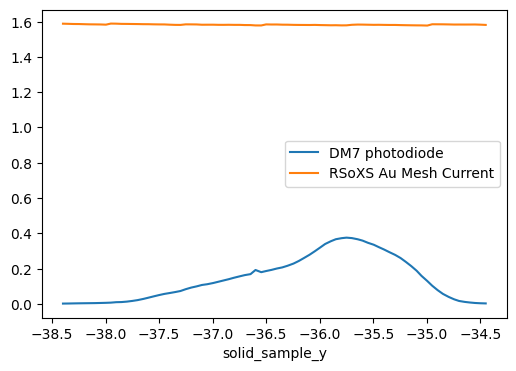

auto_redraw_plot interrupted by user.


In [6]:
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output



def auto_redraw_plot(scan_raw, x="solid_sample_y", y="DM7 photodiode",interval=2):
    prev_y_len = 0
    iter_count = 0
    try:
        while True:
            y_data = scan_raw["primary"]["data"][x].read()
            dm7_data = scan_raw["primary"]["data"][y].read()
            mesh_data = scan_raw["primary"]["data"]["RSoXS Au Mesh Current"].read()

            new_y_len = len(y_data)
            # Only redraw if y_data has grown in length
            if new_y_len > prev_y_len:
                clear_output(wait=True)
                plt.figure(figsize=(6,4))

                min_length = min(len(y_data), len(dm7_data))

                if not (len(y_data) == len(dm7_data) == len(mesh_data)):
                    print(f"Shape mismatch! y_data: {len(y_data)}, dm7_data: {len(dm7_data)}, mesh_data: {len(mesh_data)}")
                    print("Truncating to shortest length.")

                plt.plot(y_data[:min_length], dm7_data[:min_length], label="DM7 photodiode")
                plt.plot(y_data[:min_length], mesh_data[:min_length], label="RSoXS Au Mesh Current")
                plt.xlabel("solid_sample_y")
                plt.legend()
                plt.show()
                prev_y_len = new_y_len

                iter_count += 1

            time.sleep(interval)
    except KeyboardInterrupt:
        print("auto_redraw_plot interrupted by user.")

scan_raw = catalog[107760]
auto_redraw_plot(scan_raw,
    x="solid_sample_y",
    y="DM7 photodiode",
    interval=10)

In [24]:
scan_raw = catalog[107764]
scan_raw["primary"]["data"].read()

<xarray.Dataset> Size: 9kB
Dimensions:                         (time: 112)
Coordinates:
  * time                            (time) float64 896B 1.772e+09 ... 1.772e+09
Data variables:
    NSLS-II Ring Current            (time) float64 896B 499.7 499.7 ... 499.5
    RSoXS Slit 1 In Board Current   (time) float64 896B 5.88e-12 ... 4.508e-11
    RSoXS Slit 1 Out Board Current  (time) float64 896B 0.0 ... -2.907e-11
    RSoXS Au Mesh Current           (time) float64 896B 0.3488 0.353 ... 1.664
    RSoXS Sample Current            (time) float64 896B 7.171 7.171 ... 7.173
    WAXS Beamstop                   (time) float64 896B 3.638e-10 ... 7.277e-11
    DM7 photodiode                  (time) float64 896B 0.4568 0.4677 ... 1.632
    en_energy                       (time) float64 896B 250.0 251.3 ... 344.7
    en_energy_setpoint              (time) float64 896B 250.0 251.3 ... 344.7
Attributes:
    stream_name:  primary

/tmp/ipykernel_1358935/1168472966.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


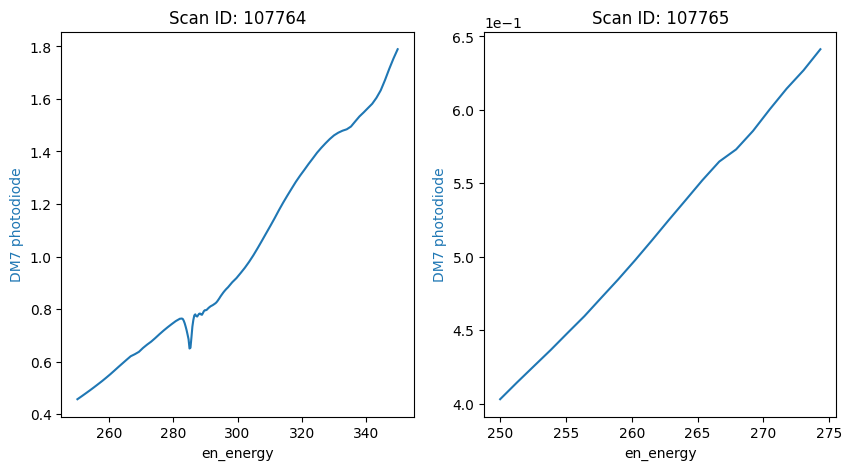

In [ ]:
def plot_scans(scan_ids, motors, signals, subplots=False):
    """"""
    if subplots:
        ...
    else:
        fig, axs = plt.subplots(ncols=len(scan_ids),
            figsize=(10, 5),
            gridspec_kw={"hspace": 0.5}
        )
        for index_scan_id, scan_id in enumerate(scan_ids):
            scan = catalog[scan_id]
            for motor in motors:
                ax = axs[index_scan_id]
                if not motor in scan["primary"]["data"].keys():
                    continue
                for i, signal in enumerate(signals):
                    if i !=0:
                        ax = axs[index_scan_id].twinx()
                    if not signal in scan["primary"]["data"].keys():
                        continue
                    ax.plot(
                        scan["primary"]["data"][motor].read(),
                        scan["primary"]["data"][signal].read(),
                        label=f"{signal}",
                        color=f"C{i}",
                    )
                    # Use scientific notation for y-axis labels
                    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                    ax.set_ylabel(f"{signal}", color=f"C{i}")
                ax.set_xlabel(f"{motor}")
            ax.set_title(f"Scan ID: {scan_id}")
        fig.tight_layout()
        fig.align_labels()
        plt.show()

plot_scans(scan_ids=[107763, 107765],
    motors=["en_energy"],
    signals=["DM7 photodiode"]#, "RSoXS Au Mesh Current"]
)

In [48]:
catalog.access_blob

{'tags': ['_ROOT_NODE_SST']}

Scan ID = 107764, Time = 2026-02-20 11:30:55, Polarization = 89.39293348452472°
Scan ID = 107765, Time = 2026-02-20 11:35:19, Polarization = 89.39293348452472°


(283.0, 290.0)

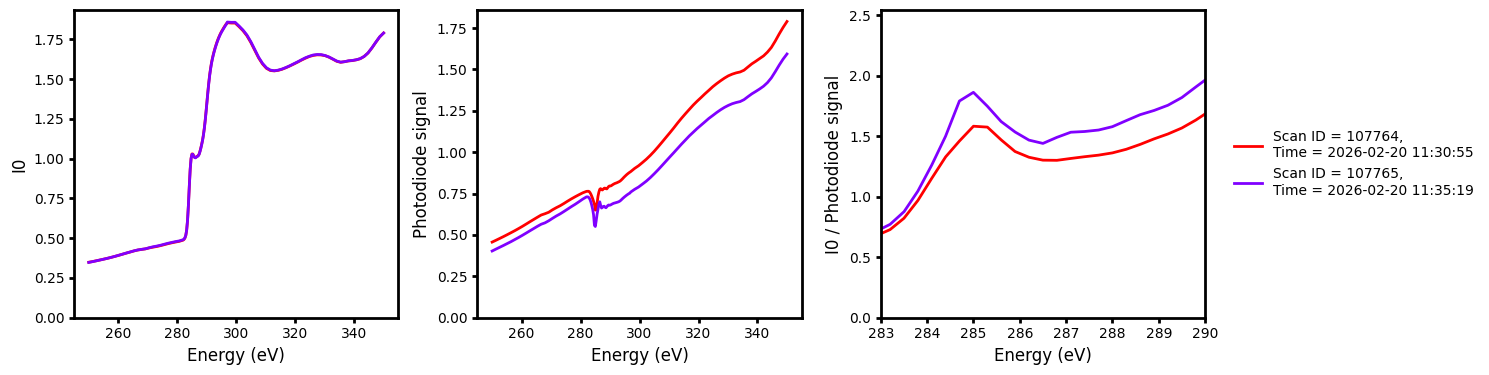

In [51]:

axs = view_export_energy_scans(scan_ids=[ 107764, 107765], export_scans=False)
axs[-1, -1].set_xlim(283, 290)

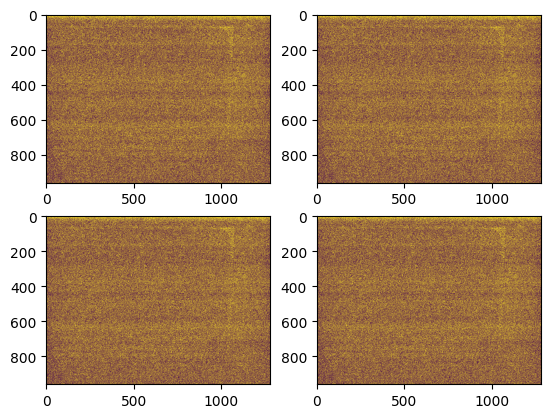

In [26]:
scan_idx = np.array([106763, 107731])

def view_fluorescence_scans(
    scan_ids,
):
    """
    """
    fig, ax = plt.subplots(ncols=2, nrows=len(scan_ids))
    for index_scan_id, scan_id in enumerate(scan_ids):
        scan = catalog[scan_id]
        imgs = scan["primary"]["data"]["FS13 Camera_image"].read()
        for i in range(len(imgs)):
            ax[index_scan_id, i].imshow(imgs[i][0], vmin=0, vmax=1e-3)

view_fluorescence_scans(scan_ids=scan_idx)